# House Price Prediction using Machine Learning

## Data Preprocessing & Exploratory Data Analysis (EDA)

### Objective
The objective of this notebook is to prepare the dataset for machine learning by performing data preprocessing and exploratory data analysis (EDA). The workflow includes loading the dataset, understanding its structure, handling missing values and duplicates, treating outliers, performing feature engineering, encoding categorical variables, scaling numerical features, and finally preparing the data for model training.

## Workflow

1. Import Required Libraries
2. Load Dataset
3. Dataset Overview
4. Identify Numerical and Categorical Features
5. Check Missing Values & Duplicate Records
6. Analyze the Target Variable (SalePrice)
7. Generate Descriptive Statistics
8. Initial Observations and Summary

## 1. Import Required Libraries

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option("display.max_rows", 100)

## 2. Load dataset

In [3]:
train_df = pd.read_csv("../dataset/raw/train.csv")
test_df = pd.read_csv("../dataset/raw/test.csv")

## 3. Dataset Overview

In [4]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
train_df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
842,843,80,RL,82.0,9020,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,5,2008,WD,Normal,174900
353,354,30,RM,60.0,8520,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,105900
491,492,50,RL,79.0,9490,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2006,WD,Normal,133000
1353,1354,50,RL,56.0,14720,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,410000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
test_df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
85,1546,50,RM,50.0,6000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,3,2010,WD,Normal
589,2050,60,RL,NaN,13355,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2008,WD,Normal
1040,2501,20,RL,58.0,9280,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2007,WD,Normal
378,1839,20,RL,50.0,4280,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2009,WD,Normal
528,1989,60,RL,NaN,8010,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal


In [8]:
train_df.shape, test_df.shape

((1460, 81), (1459, 80))

In [9]:
# colmuns
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [10]:
train_df.size,test_df.size

(118260, 116720)

#### Observation

- The training dataset contains 1460 observations and 81 columns.
- The testing dataset contains 1459 observations and 80 columns.
- The training dataset includes the target variable (SalePrice), while the testing dataset does not.

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
train_df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [13]:
test_df.dtypes.value_counts()

object     43
int64      26
float64    11
Name: count, dtype: int64

#### Observation
*The training dataset contains 43 categorical, 35 integer, and 3 floating-point features, while the testing dataset contains similar categorical columns but differences in integer and floating-point features.The difference in numerical data types is mainly due to data type inference and missing values.*

In [14]:
train_df.index, test_df.index

(RangeIndex(start=0, stop=1460, step=1),
 RangeIndex(start=0, stop=1459, step=1))

## 4. Identify Numerical and Categorical Features

In [15]:
# Numerical Features for train set
numerical_features_train = train_df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_features_train)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')


In [16]:
# Numerical Featrues for test set
numerical_features_test = test_df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_features_test)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')


In [17]:
# Categorical features for train set
categorical_features_train  = train_df.select_dtypes(include=['category', 'object','bool']).columns
print(categorical_features_train)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [18]:
# Categorical features for test set
categorical_features_test = test_df.select_dtypes(include=['category', 'object','bool']).columns
print(categorical_features_test)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [19]:
print("Numerical Features (Train):", len(numerical_features_train))
print("Categorical + Bool Features (Train):", len(categorical_features_train))

print("\nNumerical Features (Test):", len(numerical_features_test))
print("Categorical + Bool Features (Test):", len(categorical_features_test))

Numerical Features (Train): 38
Categorical + Bool Features (Train): 43

Numerical Features (Test): 37
Categorical + Bool Features (Test): 43


## 5. Missing & Duplicates check

In [20]:
missing_col_train = train_df.isna().sum()
missing_col_train = missing_col_train[missing_col_train > 0]
missing_col_train

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [21]:
missing_col_test = test_df.isna().sum()
missing_col_test = missing_col_test[missing_col_test > 0]
missing_col_test

MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageCars         1
GarageArea         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64

In [22]:
missing_percent_train = (train_df.isna().sum() / len(train_df)) * 100
missing_percent_train = missing_percent_train[missing_percent_train > 0]
print(missing_percent_train)

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64


In [23]:
missing_percent_test = (test_df.isna().sum() / len(test_df)) * 100
missing_percent_test = missing_percent_test[missing_percent_test > 0]
print(missing_percent_test)

MSZoning         0.274160
LotFrontage     15.558602
Alley           92.666210
Utilities        0.137080
Exterior1st      0.068540
Exterior2nd      0.068540
MasVnrType      61.274846
MasVnrArea       1.028101
BsmtQual         3.015764
BsmtCond         3.084304
BsmtExposure     3.015764
BsmtFinType1     2.878684
BsmtFinSF1       0.068540
BsmtFinType2     2.878684
BsmtFinSF2       0.068540
BsmtUnfSF        0.068540
TotalBsmtSF      0.068540
BsmtFullBath     0.137080
BsmtHalfBath     0.137080
KitchenQual      0.068540
Functional       0.137080
FireplaceQu     50.034270
GarageType       5.209047
GarageYrBlt      5.346127
GarageFinish     5.346127
GarageCars       0.068540
GarageArea       0.068540
GarageQual       5.346127
GarageCond       5.346127
PoolQC          99.794380
Fence           80.123372
MiscFeature     96.504455
SaleType         0.068540
dtype: float64


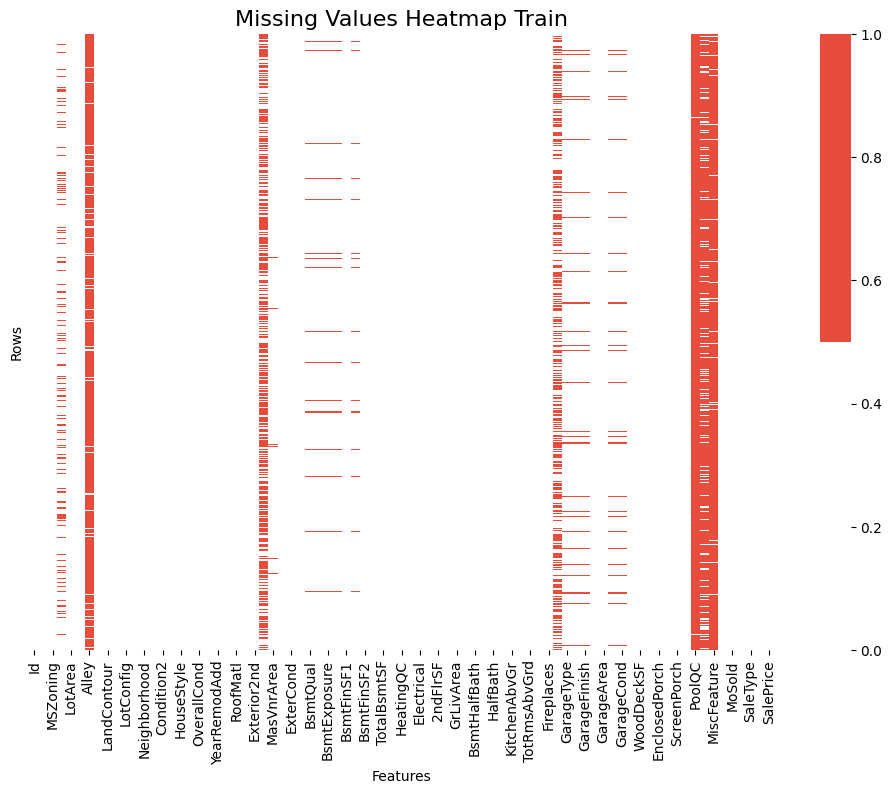

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(
    train_df.isna(),
    cmap=["#FFFFFF", "#E74C3C"],
    cbar=True,
    yticklabels=False
)

plt.title("Missing Values Heatmap Train", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Rows")

plt.show()

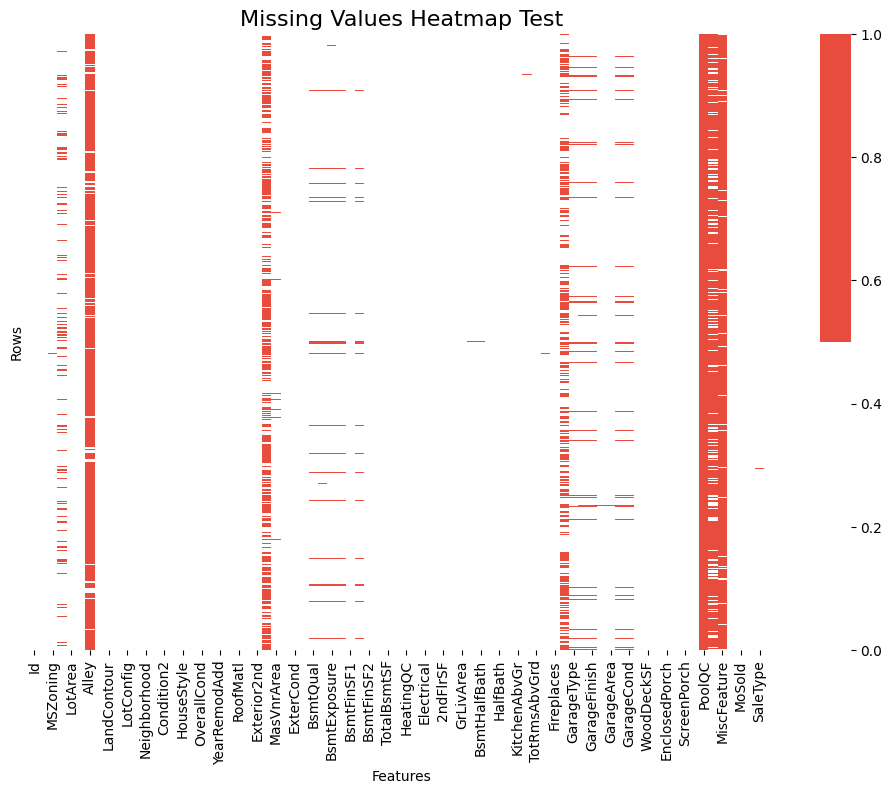

In [25]:
plt.figure(figsize=(12,8))
sns.heatmap(
    test_df.isna(),
    cmap=["#FFFFFF", "#E74C3C"],
    cbar=True,
    yticklabels=False
)

plt.title("Missing Values Heatmap Test", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Rows")

plt.show()

In [26]:
train_df.duplicated().sum()

np.int64(0)

In [27]:
test_df.duplicated().sum()

np.int64(0)

### Analysis

The training and test datasets contain missing values in several features. Most missing values occur in attributes such as `Alley`, `PoolQC`, `Fence`, `MiscFeature`, `FireplaceQu`, and several basement and garage-related features. Some columns have only a few missing records (e.g., `Electrical`, `MasVnrArea`), while others have a very high percentage of missing values, indicating that the corresponding feature may not exist for many houses rather than representing data collection errors.

No duplicate records were found in either the training or test dataset.

## 6. Analyze the Target Variable (SalePrice)

In [28]:
train_df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [29]:
# Skewness 
print(f"\nSkewness : {train_df['SalePrice'].skew():.3f}")
print(f"Kurtosis : {train_df['SalePrice'].kurt():.3f}")


Skewness : 1.883
Kurtosis : 6.536


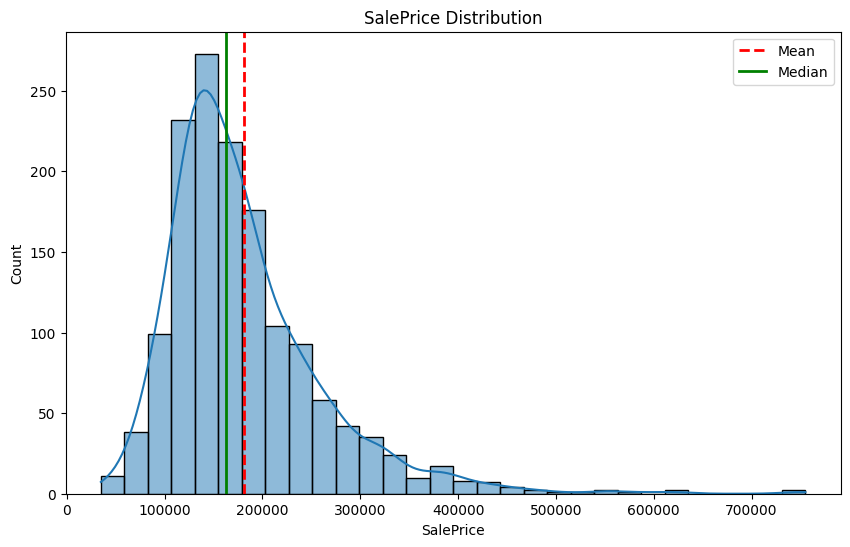

In [32]:
# Distribution plot
plt.figure(figsize=(10,6))

sns.histplot(
    train_df["SalePrice"],
    bins=30,
    kde=True
)
plt.axvline(
    train_df["SalePrice"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Mean"
)
plt.axvline(
    train_df["SalePrice"].median(),
    color="green",
    linestyle="-",
    linewidth=2,
    label="Median"
)
plt.legend()

plt.title("SalePrice Distribution")
plt.show()

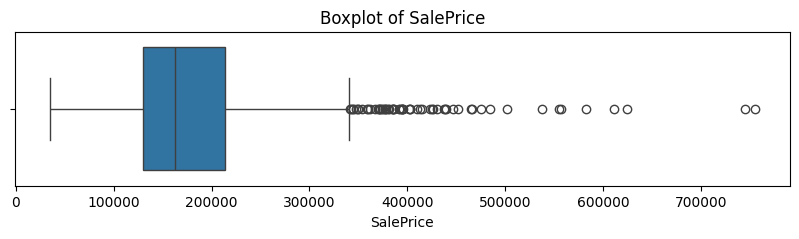

In [31]:
# Boxplot 
plt.figure(figsize=(10,2))

sns.boxplot(
    x=train_df["SalePrice"]
)
plt.title("Boxplot of SalePrice")

plt.show()

### Observations

- The boxplot reveals several extreme values (potential outliers) in the `SalePrice` variable.
- These observations represent properties with exceptionally high sale prices compared to the majority of houses.
- At the EDA stage, these values are only identified and will be further evaluated during the preprocessing phase to determine whether they should be retained, transformed, or removed.

## 7. Generate Descriptive Statistics

In [34]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [35]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1459.0,2190.000000,421.321334,1461.0,1825.50,2190.0,2554.50,2919.0
MSSubClass,1459.0,57.378341,42.746880,20.0,20.00,50.0,70.00,190.0
LotFrontage,1232.0,68.580357,22.376841,21.0,58.00,67.0,80.00,200.0
LotArea,1459.0,9819.161069,4955.517327,1470.0,7391.00,9399.0,11517.50,56600.0
OverallQual,1459.0,6.078821,1.436812,1.0,5.00,6.0,7.00,10.0
OverallCond,1459.0,5.553804,1.113740,1.0,5.00,5.0,6.00,9.0
YearBuilt,1459.0,1971.357779,30.390071,1879.0,1953.00,1973.0,2001.00,2010.0
YearRemodAdd,1459.0,1983.662783,21.130467,1950.0,1963.00,1992.0,2004.00,2010.0
MasVnrArea,1444.0,100.709141,177.625900,0.0,0.00,0.0,164.00,1290.0
BsmtFinSF1,1458.0,439.203704,455.268042,0.0,0.00,350.5,753.50,4010.0


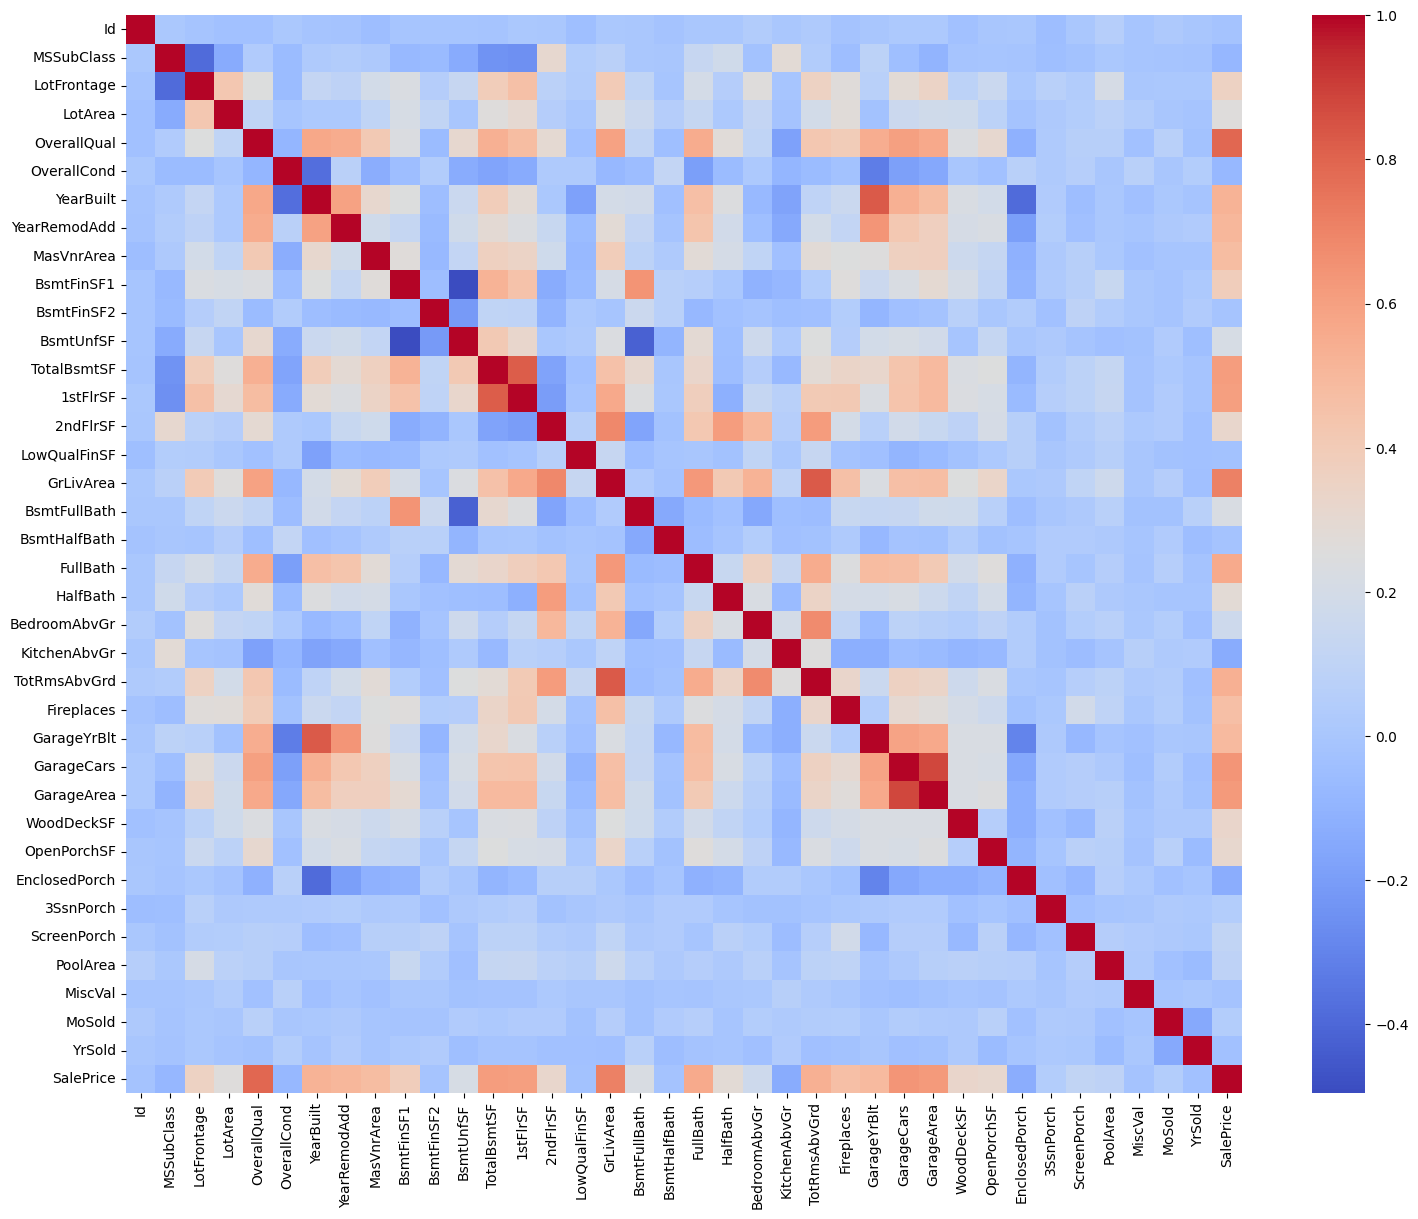

In [36]:
plt.figure(figsize=(18,14))
sns.heatmap(train_df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

## 8. Initial Observations and Summary

- The training dataset contains **81 features**, including the target variable (`SalePrice`), while the test dataset contains **80 features** without the target variable.
- The dataset consists of both **numerical** and **categorical** features, representing various structural, physical, and neighborhood characteristics of residential properties.
- Several features contain missing values. High missing rates are mainly observed in `Alley`, `PoolQC`, `Fence`, `MiscFeature`, and some basement and garage-related features, suggesting that the absence of these attributes is common rather than indicating data entry errors.
- No duplicate records were found in either the training or test dataset.
- The target variable (`SalePrice`) is positively skewed and contains several extreme values, indicating the presence of high-value properties. A transformation may improve its distribution for linear regression models.
- Descriptive statistics show considerable variation among numerical features, with differences in scales, ranges, and distributions, suggesting that feature scaling may be required during preprocessing.
- Categorical features contain varying numbers of unique categories, which will require appropriate encoding before model training.
- Overall, the dataset is well-structured and suitable for regression analysis after appropriate preprocessing, including handling missing values, feature encoding, feature scaling, and potential treatment of outliers.